In [1]:
from diffuser_simulator import Diffuser

parameters_range={"x0": [0, 10],"x1": [0, 100]}
output_names = ["top_flux"]

simulator = Diffuser(parameters_range, output_names)


/home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/festim/coupled_heat_hydrogen_problem.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  import tqdm.autonotebook


In [2]:
import torch
true_parameters = torch.Tensor([[1, 100]])

observation = simulator.forward(true_parameters, allow_failures=False)

print("Observation:", observation)

Observation: tensor([4.1628])


In [3]:
n_samples = 80

X = simulator.sample_inputs(n_samples)

X.shape

torch.Size([80, 2])

In [4]:
Y, _ = simulator.forward_batch(X, allow_failures=False)
Y.shape

Running simulations: 100%|██████████| 80.0/80.0 [00:05<00:00, 14.8sample/s]


torch.Size([80])

In [5]:
Y

tensor([22.8489, 27.0150, 22.6321, 30.7769, 11.2564, 19.5312, 27.0349, 35.0971,
         9.8514, 17.4729,  4.9120,  0.4983, 12.1470, 21.5154, 11.5201, 19.2678,
        20.2717, 19.1359,  1.2368, 27.4252,  8.9565, 32.7460, 21.7005, 29.8443,
         6.0113, 18.2195, 16.5921, 33.4565,  8.7831, 30.5239, 30.1774, 24.6150,
        24.0113, 36.8897, 22.6984, 20.8474,  4.4271,  0.3569, 29.1972,  5.5975,
        26.3656,  6.8287,  3.3869, 12.6522, 11.0668,  4.7601,  6.0312, 23.5511,
        35.7952,  7.1946,  2.8820, 27.9668, 23.5764, 16.9483, 25.4342, 31.4864,
         8.8437,  9.6525, 35.9778, 12.2393,  2.7421, 23.4757,  4.6130, 11.0089,
         2.0447,  1.5352, 24.6422,  7.3685, 16.0909, 30.0085, 30.9738, 28.0729,
        11.1330, 14.2931, 25.9716, 30.1529, 23.3532, 14.3102, 17.6267, 21.7822])

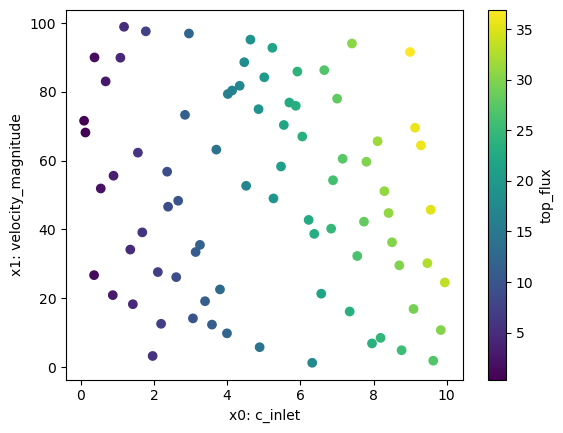

In [8]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis')
plt.xlabel('x0: c_inlet')
plt.ylabel('x1: velocity_magnitude')
plt.colorbar(label='top_flux')
plt.show()

In [10]:
from autoemulate import AutoEmulate
# Run AutoEmulate with default settings
ae = AutoEmulate(X, Y, log_level="info")

INFO    2026-04-08 09:51:37,619 - autoemulate - Comparing ['GaussianProcessMatern32', 'GaussianProcessRBF', 'RadialBasisFunctions', 'PolynomialRegression', 'MLP', 'EnsembleMLP']
INFO    2026-04-08 09:51:37,620 - autoemulate - Running Model: GaussianProcessMatern32: 1/6 (attempt 1/3)
INFO    2026-04-08 09:52:01,763 - autoemulate - Finished running Model: GaussianProcessMatern32

INFO    2026-04-08 09:52:01,763 - autoemulate - Running Model: GaussianProcessRBF: 2/6 (attempt 1/3)
INFO    2026-04-08 09:52:16,134 - autoemulate - Finished running Model: GaussianProcessRBF

INFO    2026-04-08 09:52:16,135 - autoemulate - Running Model: RadialBasisFunctions: 3/6 (attempt 1/3)
INFO    2026-04-08 09:52:16,534 - autoemulate - Finished running Model: RadialBasisFunctions

INFO    2026-04-08 09:52:16,535 - autoemulate - Running Model: PolynomialRegression: 4/6 (attempt 1/3)
INFO    2026-04-08 09:52:30,907 - autoemulate - Finished running Model: PolynomialRegression

INFO    2026-04-08 09:52:30,908 

In [11]:
ae.summarise()

,model_name,x_transforms,y_transforms,params,r2_test,r2_test_std,rmse_test,rmse_test_std,r2_train,r2_train_std,rmse_train,rmse_train_std
2,RadialBasisFunctions,[StandardizeTransform()],[StandardizeTransform()],"{'kernel': 'quintic', 'degree': 2, 'smoothing'...",0.999961,0.000025,0.049503,0.016146,0.999999,3.757333e-07,0.008266,0.002120
1,GaussianProcessRBF,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 200, 'lr': 0.1, 'likelihood_cls': <...",0.999852,0.000064,0.101487,0.027223,0.999976,4.953655e-06,0.050375,0.004728
0,GaussianProcessMatern32,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 200, 'lr': 0.05, 'likelihood_cls': ...",0.999727,0.000303,0.118112,0.037678,0.999991,2.098332e-06,0.029679,0.003817
3,PolynomialRegression,[StandardizeTransform()],[StandardizeTransform()],"{'lr': 0.1, 'epochs': 500, 'batch_size': 8, 's...",0.998506,0.000757,0.310633,0.039227,0.999251,2.142787e-04,0.272913,0.032488
4,MLP,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 200, 'layer_dims': [16, 8], 'lr': 0...",0.937892,0.043640,2.013677,0.254863,0.980218,3.697063e-03,1.445470,0.161960
5,EnsembleMLP,[StandardizeTransform()],[StandardizeTransform()],"{'n_emulators': 4, 'epochs': 100, 'layer_dims'...",0.884234,0.047533,2.819952,0.221847,0.929279,3.463120e-03,2.731428,0.223264


In [12]:
# best = ae.best_result()
best = ae.results[0]
print("Model with id: ", best.id, " performed best: ", best.model_name)

Model with id:  0  performed best:  GaussianProcessMatern32


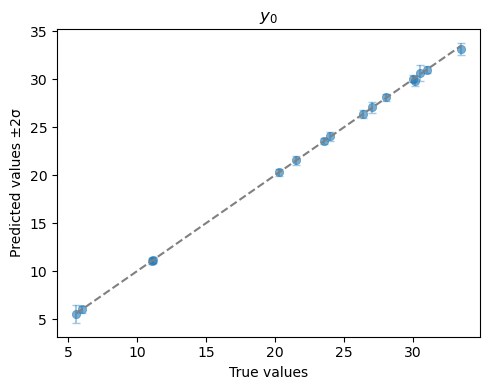

In [13]:
ae.plot_preds(best)

WARNING 2026-04-08 09:59:36,783 - py.warnings - /tmp/ipykernel_221287/2904544388.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], cmap='viridis', edgecolor='k')



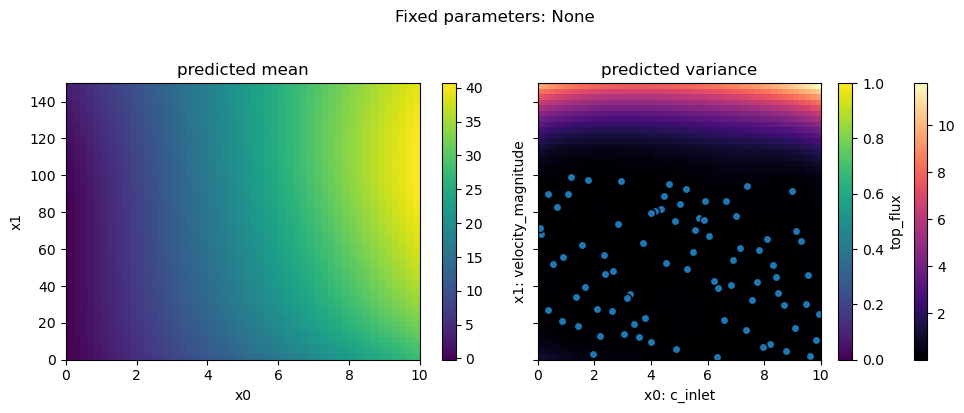

In [ ]:
from autoemulate.core.plotting import create_and_plot_slice
# ae.plot_surface(best.model, parameters_range={"x0": [0, 10],"x1": [0, 150]}, quantile=0.5)
fig, axs = create_and_plot_slice(best.model, parameters_range={"x0": [0, 10],"x1": [0, 150]}, quantile=0.5, param_pair=(0, 1))
# overlay scatter on previous figure already displayed
plt.scatter(X[:, 0], X[:, 1], cmap='viridis', edgecolor='k')
plt.xlabel('x0: c_inlet')
plt.ylabel('x1: velocity_magnitude')
plt.show()
